In [33]:
# Cell 1: Install and import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')



In [34]:
data=pd.read_csv("/content/customer_churn_dataset.csv")

In [35]:
data.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,Yes,No,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6418 entries, 0 to 6417
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6418 non-null   object 
 1   Gender                       6418 non-null   object 
 2   Age                          6418 non-null   int64  
 3   Married                      6418 non-null   object 
 4   State                        6418 non-null   object 
 5   Number_of_Referrals          6418 non-null   int64  
 6   Tenure_in_Months             6418 non-null   int64  
 7   Value_Deal                   2870 non-null   object 
 8   Phone_Service                6418 non-null   object 
 9   Multiple_Lines               5796 non-null   object 
 10  Internet_Service             6418 non-null   object 
 11  Internet_Type                5028 non-null   object 
 12  Online_Security              5028 non-null   object 
 13  Online_Backup     

In [37]:
data.describe()

,Age,Number_of_Referrals,Tenure_in_Months,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue
count,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000
mean,47.070739,7.427859,17.342786,63.652867,2280.374858,1.924944,6.718604,748.703468,3033.871987
std,16.703633,4.621519,10.576391,31.188823,2268.049985,7.849083,24.722533,847.672844,2866.505426
min,18.000000,0.000000,1.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,33.000000,3.000000,8.000000,30.562500,395.725000,0.000000,0.000000,70.805000,603.742500
50%,46.000000,7.000000,16.000000,70.100000,1396.125000,0.000000,0.000000,407.475000,2108.635000
75%,60.000000,11.000000,27.000000,89.750000,3783.600000,0.000000,0.000000,1182.917500,4801.537500
max,85.000000,15.000000,36.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


In [38]:
data.shape

(6418, 32)

**Data Pre-Processing**

In [45]:

# Cell 4: Drop columns not useful for prediction (safe version)

cols_to_drop = ['Customer_ID', 'Churn_Category', 'Churn_Reason']

# Only drop columns that actually exist
cols_to_drop = [col for col in cols_to_drop if col in data.columns]

data.drop(columns=cols_to_drop, inplace=True)


In [46]:
data = data[data['Customer_Status'].isin(['Stayed', 'Churned'])]

data['Churn'] = (data['Customer_Status'] == 'Churned').astype(int)
data.drop(columns=['Customer_Status'], inplace=True)

In [47]:
internet_related_cols = [
    'Internet_Type', 'Online_Security', 'Online_Backup',
    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV',
    'Streaming_Movies', 'Streaming_Music', 'Unlimited_Data'
]

for col in internet_related_cols:
    if col in data.columns:
        data[col].fillna('No Service', inplace=True)

if 'Multiple_Lines' in data.columns:
    data['Multiple_Lines'].fillna('No Service', inplace=True)

if 'Value_Deal' in data.columns:
    data['Value_Deal'].fillna('No Deal', inplace=True)

In [48]:
from sklearn.preprocessing import LabelEncoder

le_dict = {}  # saving encoders for future prediction use
cat_cols = data.select_dtypes(include='object').columns.tolist()

print("Encoding columns:", cat_cols)

for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    le_dict[col] = le

Encoding columns: ['Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup', 'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies', 'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing', 'Payment_Method']


In [49]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['Churn'])
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [50]:
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print(f"\nChurn rate in train : {y_train.mean():.2%}")
print(f"Churn rate in test  : {y_test.mean():.2%}")

Training samples : 4805
Testing  samples : 1202

Churn rate in train : 28.82%
Churn rate in test  : 28.87%


In [51]:

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=5, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [53]:
print(" Random Forest model trained!")
print(f"   Trees     : {rf_model.n_estimators}")
print(f"   Features  : {rf_model.n_features_in_}")

 Random Forest model trained!
   Trees     : 200
   Features  : 28


In [55]:


y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

roc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc:.4f}")

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Stayed       0.89      0.89      0.89       855
     Churned       0.72      0.73      0.73       347

    accuracy                           0.84      1202
   macro avg       0.81      0.81      0.81      1202
weighted avg       0.84      0.84      0.84      1202

ROC-AUC Score: 0.8919


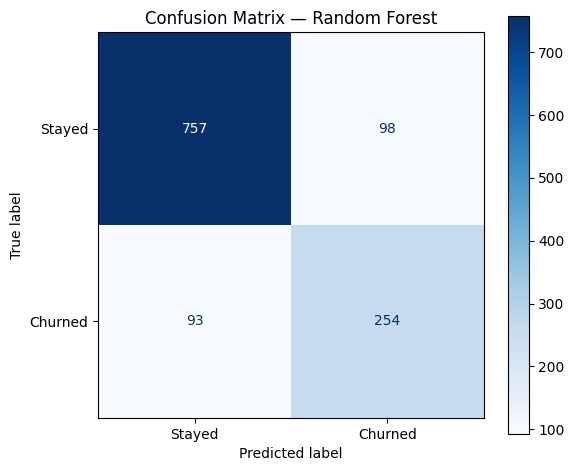

In [56]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Stayed', 'Churned'],
    cmap='Blues', ax=ax
)
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()

In [59]:
# Cell 14: Predict churn on new customers
# Fill in your actual new customer values below

new_customers = pd.DataFrame({
    'Gender':                      ['Male', 'Female'],
    'Age':                         [35, 60],
    'Married':                     ['Yes', 'No'],
    'State':                       ['Maharashtra', 'Delhi'],
    'Number_of_Referrals':         [5, 0],
    'Tenure_in_Months':            [6, 24],
    'Value_Deal':                  ['No Deal', 'Deal 3'],
    'Phone_Service':               ['Yes', 'Yes'],
    'Multiple_Lines':              ['No', 'No Service'],
    'Internet_Service':            ['Yes', 'Yes'],
    'Internet_Type':               ['Fiber Optic', 'DSL'],
    'Online_Security':             ['No', 'Yes'],
    'Online_Backup':               ['No', 'No'],
    'Device_Protection_Plan':      ['No', 'Yes'],
    'Premium_Support':             ['No', 'No'],
    'Streaming_TV':                ['Yes', 'No'],
    'Streaming_Movies':            ['No', 'No'],
    'Streaming_Music':             ['No', 'No'],
    'Unlimited_Data':              ['Yes', 'Yes'],
    'Contract':                    ['Month-to-Month', 'One Year'],
    'Paperless_Billing':           ['Yes', 'No'],
    'Payment_Method':              ['Bank Withdrawal', 'Credit Card'],
    'Monthly_Charge':              [85.0, 55.0],
    'Total_Charges':               [510.0, 1320.0],
    'Total_Refunds':               [0, 0],
    'Total_Extra_Data_Charges':    [0, 10],
    'Total_Long_Distance_Charges': [150.0, 200.0],
    'Total_Revenue':               [660.0, 1530.0],
})

# Encode using saved encoders from training
new_encoded = new_customers.copy()
for col in new_encoded.select_dtypes(include='object').columns:
    if col in le_dict:
        le = le_dict[col]
        # Handle unseen labels safely
        new_encoded[col] = new_encoded[col].apply(
            lambda x: le.transform([x])[0] if x in le.classes_ else -1
        )

churn_prob = rf_model.predict_proba(new_encoded)[:, 1]
churn_pred = rf_model.predict(new_encoded)

result = new_customers[['Age', 'Tenure_in_Months', 'Contract', 'Monthly_Charge']].copy()
result['Churn_Prediction'] = [' CHURNER' if p == 1 else ' STAYING' for p in churn_pred]
result['Churn_Probability'] = [f"{p:.1%}" for p in churn_prob]

print(result.to_string(index=False))

 Age  Tenure_in_Months       Contract  Monthly_Charge Churn_Prediction Churn_Probability
  35                 6 Month-to-Month            85.0          CHURNER             85.6%
  60                24       One Year            55.0          STAYING              8.2%


**Accuracy**

In [60]:
train_acc = accuracy_score(y_train, rf_model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f"Training Accuracy : {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Testing  Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")


Training Accuracy : 0.9249 (92.49%)
Testing  Accuracy : 0.8411  (84.11%)


In [63]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

metrics = {
    'Accuracy'  : accuracy_score(y_test, y_pred),
    'Precision' : precision_score(y_test, y_pred),
    'Recall'    : recall_score(y_test, y_pred),
    'F1 Score'  : f1_score(y_test, y_pred),
    'ROC-AUC'   : roc_auc_score(y_test, y_prob)
}

print("=" * 35)
print("      MODEL PERFORMANCE METRICS")
print("=" * 35)
for metric, value in metrics.items():
    print(f"  {metric:<12} :  {value:.4f}  ({value*100:.2f}%)")
print("=" * 35)

      MODEL PERFORMANCE METRICS
  Accuracy     :  0.8411  (84.11%)
  Precision    :  0.7216  (72.16%)
  Recall       :  0.7320  (73.20%)
  F1 Score     :  0.7268  (72.68%)
  ROC-AUC      :  0.8919  (89.19%)


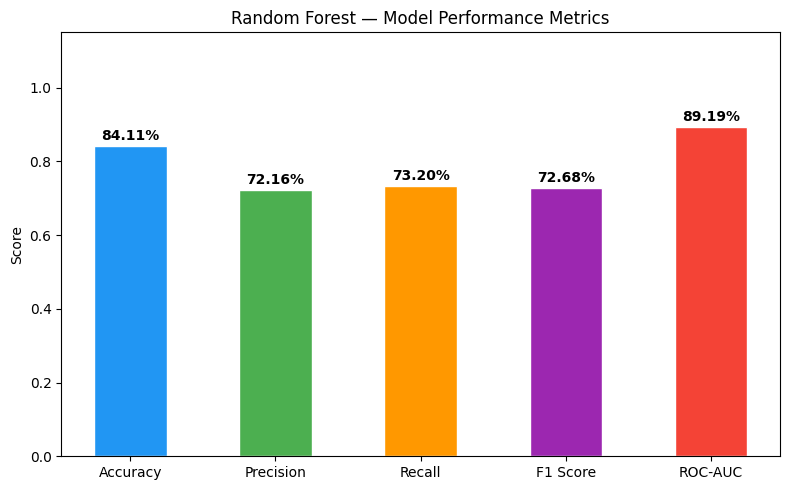

In [64]:
plt.figure(figsize=(8, 5))
bars = plt.bar(metrics.keys(), metrics.values(),
               color=['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336'],
               edgecolor='white', width=0.5)

# Add value labels on top of each bar
for bar, val in zip(bars, metrics.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val*100:.2f}%',
             ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.15)
plt.ylabel('Score')
plt.title('Random Forest — Model Performance Metrics')
plt.tight_layout()
plt.show()